In [18]:
from func import *
from plot_func import *
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from xgboost import XGBRegressor
from scipy.stats import randint, uniform, loguniform

In [19]:
train_df = pd.read_csv("processed7/train_data.csv")
test_df = pd.read_csv("processed7/test_data.csv")

train_df["logClosePrice"] = np.log1p(train_df["ClosePrice"])
train_df.drop(columns=["ClosePrice"], inplace=True)
test_df["logClosePrice"] = np.log1p(test_df["ClosePrice"])
test_df.drop(columns=["ClosePrice"], inplace=True)

In [20]:
X_train = train_df.drop(columns=["logClosePrice"], axis=1)

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

nunique = X_train[cat_cols].nunique(dropna=False)

low_card_cols = nunique[(nunique <= 20)].index.tolist()
high_card_cols = nunique[(nunique >= 20)].index.tolist()

In [35]:
en_full = make_model_pipeline(
    model=ElasticNet(alpha=0.01778279410038923,
                     l1_ratio=0.05),
    num_cols=num_cols,
    low_card_cols=low_card_cols,
    high_card_cols=high_card_cols
)

xgb_num = make_model_numeric_only_pipeline(
    model=XGBRegressor(n_estimators=1219,
                       learning_rate=0.05383345943137039,
                       max_depth=6,
                       subsample=0.755325405158244,
                       colsample_bytree=0.7844598129752072,
                       min_child_weight=14,
                       reg_lambda=4.736558858366902,
                       reg_alpha=1.10973369349242),
    num_cols=num_cols,
    num_scaler=None
)

stack = StackingRegressor(
    estimators=[
        ("en_full", en_full),
        ("xgb_num", xgb_num),
    ],
    final_estimator=XGBRegressor(
        max_depth=2,
        n_estimators=200,
        learning_rate=0.05
    ),
    cv=5,
    n_jobs=-1
)
# Fit on log target
y_train = train_df["logClosePrice"]
stack.fit(X_train, y_train)

# Predict log target
X_test = test_df.drop("logClosePrice", axis=1)
y_test = test_df["logClosePrice"]
y_train_pred = stack.predict(X_train)
y_pred = stack.predict(X_test)

stack_metrics = compute_metrics(y_test, y_pred, y_train, y_train_pred)

In [36]:
stack_metrics

{'R2(log)': 0.9256454618996856,
 'R2': 0.879826371647398,
 'MAPE': 11.72432111154959,
 'MdAPE': 8.031679878048775,
 'RMSE': 304207.8167374893,
 'MAE': 142508.381233087,
 'Bias(mean residual)': -6035.597762281446,
 'APE_95pct': 34.85138057065213,
 'APE_99pct': 60.63978757952128,
 'APE_max': 197.29516071428594,
 'Train_R2(log)': 0.9538091838906688,
 'Test_R2(log)': 0.9256454618996856,
 'R2_gap': 0.02816372199098327}

# Residual Diagnosis

In [37]:
residual = y_test - y_pred

ape = abs(residual) / y_test * 100

y_test_exp = np.expm1(y_test)

y_pred_exp = np.expm1(y_pred)

residual_exp = y_test_exp - y_pred_exp

ape_exp = abs(residual_exp) / y_test_exp * 100

## (0) Distribution of residual and APE

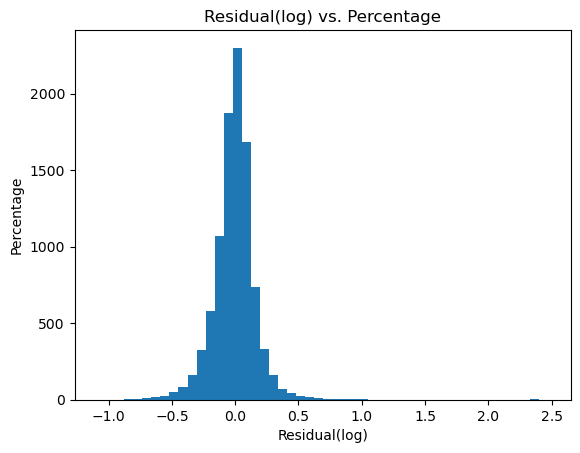

In [38]:
import matplotlib.pyplot as plt

plt.hist(residual,
         bins=50)
plt.xlabel("Residual(log)")
plt.ylabel("Percentage")
plt.title("Residual(log) vs. Percentage")
plt.show()

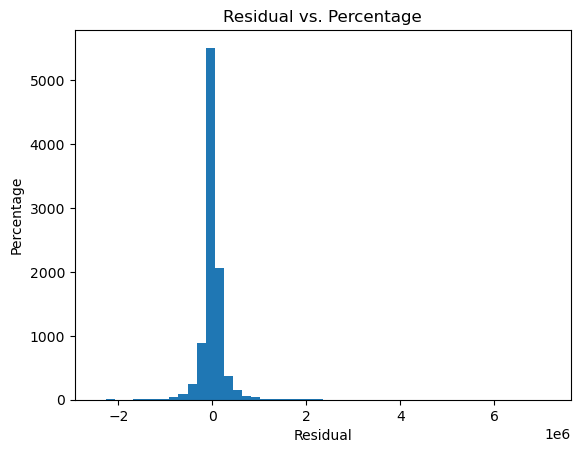

In [39]:
plt.hist(residual_exp,
         bins=50)
plt.xlabel("Residual")
plt.ylabel("Percentage")
plt.title("Residual vs. Percentage")
plt.show()

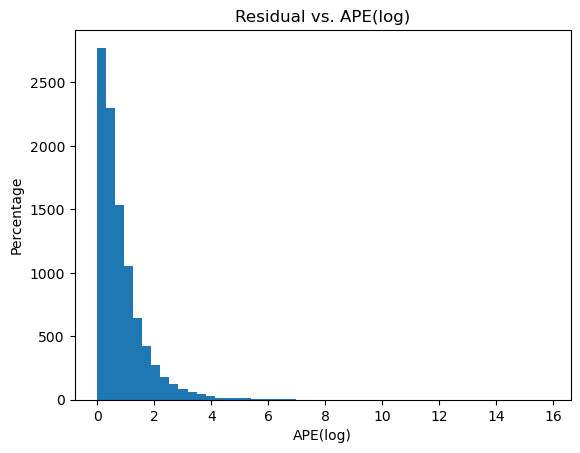

In [40]:
plt.hist(ape,
         bins=50)
plt.xlabel("APE(log)")
plt.ylabel("Percentage")
plt.title("Residual vs. APE(log)")
plt.show()

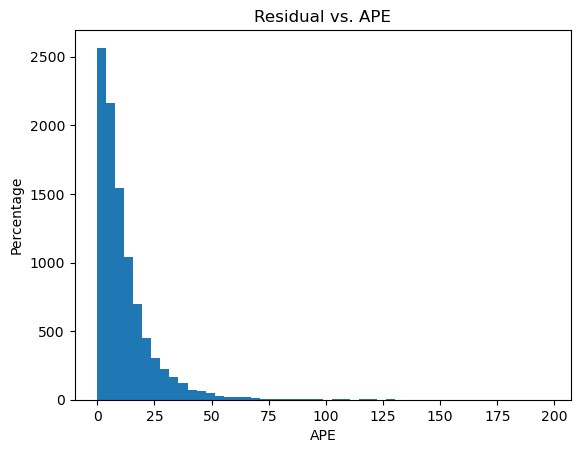

In [41]:
plt.hist(ape_exp,
         bins=50)
plt.xlabel("APE")
plt.ylabel("Percentage")
plt.title("Residual vs. APE")
plt.show()

## (1) Residual vs Predicted Price

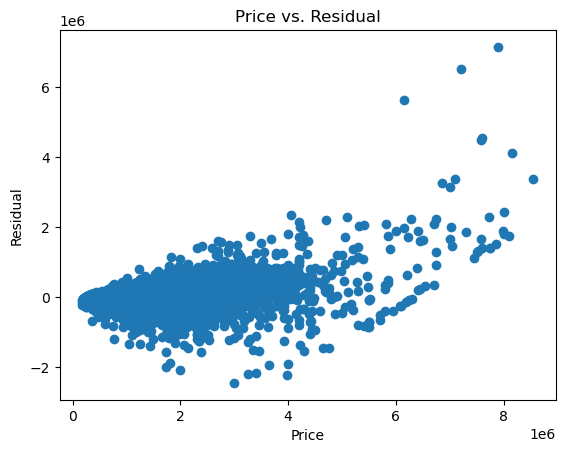

In [42]:
plt.scatter(y_test_exp, residual_exp)
plt.xlabel("Price")
plt.ylabel("Residual")
plt.title("Price vs. Residual")
plt.show()

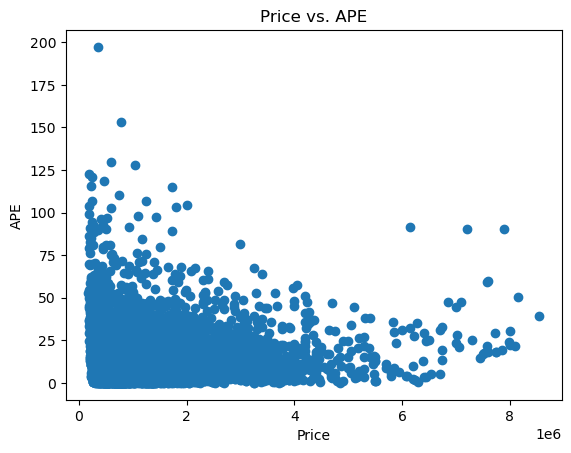

In [43]:
plt.scatter(y_test_exp, ape_exp)
plt.xlabel("Price")
plt.ylabel("APE")
plt.title("Price vs. APE")
plt.show()

## (2) Residual vs Latitude / Longitude

In [44]:
plot_test_df = test_df.copy()
plot_test_df["y_true"] = np.asarray(y_test_exp)
plot_test_df[f"y_pred"] = np.asarray(y_pred_exp)
plot_test_df["residual"] = residual_exp
plot_test_df["ape_pct"] = ape_exp


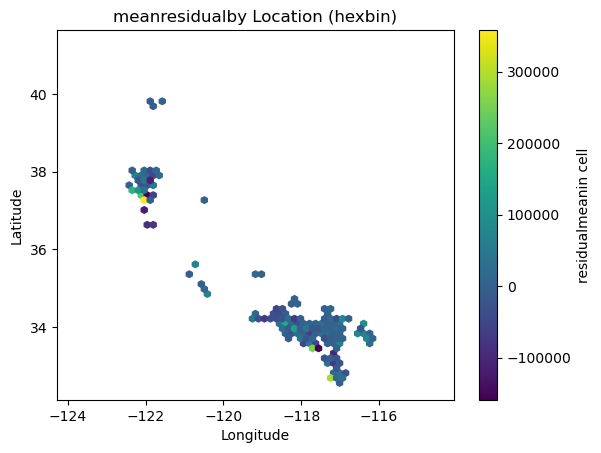

In [45]:
plot_hexbin(df=plot_test_df,
            target_col="residual")

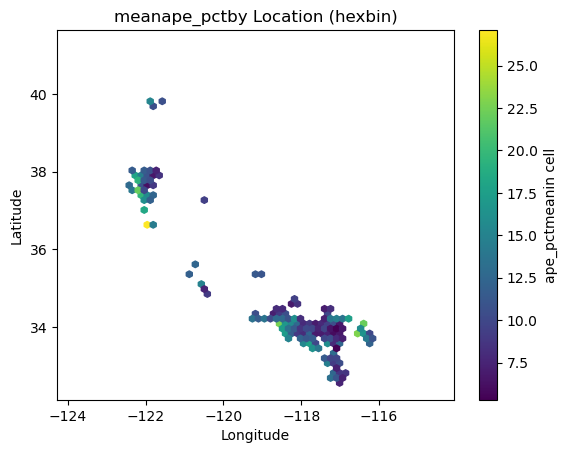

In [46]:
plot_hexbin(df=plot_test_df,
            target_col="ape_pct")

## (2) create geo clusters for market statistics

In [65]:
from sklearn.cluster import KMeans

coords_train = X_train[["Latitude", "Longitude"]]

kmeans = KMeans(
    n_clusters=50,
    random_state=42,
    n_init=10
)

X_train["geo_cluster_id"] = kmeans.fit_predict(coords_train)

X_test["geo_cluster_id"] = kmeans.predict(
    X_test[["Latitude","Longitude"]]
)

In [66]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

In [67]:
en_full_cluster = make_model_pipeline(
    model=ElasticNet(alpha=0.01778279410038923,
                     l1_ratio=0.05),
    num_cols=num_cols,
    low_card_cols=low_card_cols,
    high_card_cols=high_card_cols
)

xgb_num_cluster = make_model_numeric_only_pipeline(
    model=XGBRegressor(n_estimators=1219,
                       learning_rate=0.05383345943137039,
                       max_depth=6,
                       subsample=0.755325405158244,
                       colsample_bytree=0.7844598129752072,
                       min_child_weight=14,
                       reg_lambda=4.736558858366902,
                       reg_alpha=1.10973369349242),
    num_cols=num_cols,
    num_scaler=None
)

stack_cluster = StackingRegressor(
    estimators=[
        ("en_full", en_full_cluster),
        ("xgb_num", xgb_num_cluster),
    ],
    final_estimator=XGBRegressor(
        max_depth=2,
        n_estimators=200,
        learning_rate=0.05
    ),
    cv=5,
    n_jobs=-1
)

stack_cluster.fit(X_train, y_train)

# Predict log target
y_train_pred = stack_cluster.predict(X_train)
y_pred = stack_cluster.predict(X_test)

stack_cluster_metrics = compute_metrics(y_test, y_pred, y_train, y_train_pred)

In [68]:
stack_cluster_metrics

{'R2(log)': 0.9262895866079841,
 'R2': 0.8807758980484056,
 'MAPE': 11.662900806394022,
 'MdAPE': 7.993387500000043,
 'RMSE': 303003.61661033187,
 'MAE': 142029.2936709643,
 'Bias(mean residual)': -6102.34981948638,
 'APE_95pct': 35.11083540721302,
 'APE_99pct': 61.033078007204715,
 'APE_max': 190.63439285714307,
 'Train_R2(log)': 0.9544999311997585,
 'Test_R2(log)': 0.9262895866079841,
 'R2_gap': 0.028210344591774406}

In [69]:
df = pd.DataFrame([stack_metrics, stack_cluster_metrics], index=["origin", "cluster_data"]).T
df["diff"] = df["cluster_data"] - df["origin"]

print(df)

                            origin   cluster_data         diff
R2(log)                   0.925645       0.926290     0.000644
R2                        0.879826       0.880776     0.000950
MAPE                     11.724321      11.662901    -0.061420
MdAPE                     8.031680       7.993388    -0.038292
RMSE                 304207.816737  303003.616610 -1204.200127
MAE                  142508.381233  142029.293671  -479.087562
Bias(mean residual)   -6035.597762   -6102.349819   -66.752057
APE_95pct                34.851381      35.110835     0.259455
APE_99pct                60.639788      61.033078     0.393290
APE_max                 197.295161     190.634393    -6.660768
Train_R2(log)             0.953809       0.954500     0.000691
Test_R2(log)              0.925645       0.926290     0.000644
R2_gap                    0.028164       0.028210     0.000047


## (3) CV-safe group anchor with optional smoothing

In [77]:
from sklearn.model_selection import KFold

def add_cv_local_price_anchors(
        X_train: pd.DataFrame,
        y_train_log: np.ndarray,
        X_test: pd.DataFrame,
        group_cols=("geo_cluster_id",),
        n_splits=5,
        random_state=42,
        min_count=5,
        smoothing=50.0,
        add_mean=True,
        add_std=False,
):
    """
    CV-safe local price anchors (for log-price target):
        - Train: out-of-fold (OOF) group stats
        - Test: stats from full train only

    Produces features (per group col):
      - {g}__ylog_median, {g}__count
      - optional {g}__ylog_mean, {g}__ylog_std
    Uses shrinkage for median/mean:
      anchor = w * group_stat + (1-w) * global_stat
      where w = count / (count + smoothing)
    """
    X_train = X_train.copy()
    X_test = X_test.copy()

    y_train_log = np.asarray(y_train_log)

    # Global fallback statistics on log-price
    global_median = float(np.median(y_train_log))
    global_mean = float(np.mean(y_train_log))
    global_std = float(np.std(y_train_log))

    # Define cross-validation split scheme for leakage-safe encodings
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # For each grouping key
    for g in group_cols:

        # Create arrays to store out-of-fold (OOF) features for TRAIN
        #    Initialize to NaN so we can fill fold-by-fold.
        oof_median = np.full(len(X_train), np.nan, dtype=float)
        oof_mean   = np.full(len(X_train), np.nan, dtype=float)
        oof_std    = np.full(len(X_train), np.nan, dtype=float)
        oof_count  = np.full(len(X_train), 0.0, dtype=float)

        # Loop over CV folds: (tr_idx = indices used to compute group stats)
        #                       (va_idx = indices to receive OOF stats)
        for tr_idx, va_idx in kf.split(X_train):
            X_tr = X_train.iloc[tr_idx]      # fold training features
            X_va = X_train.iloc[va_idx]      # fold validation features
            y_tr = y_train_log[tr_idx]       # fold training targets (log-price)

            # Build a temp df: group value, y
            tmp = pd.DataFrame({g: X_tr[g].values, "y": y_tr})

            # Compute group-wise statistics on fold-train only
            grp = tmp.groupby(g)["y"].agg(["median", "mean", "std", "count"])

            # If group is too small, mark its stats as NaN (fallback to global)
            grp.loc[grp["count"] < min_count, ["median", "mean", "std"]] = np.nan

            # For each row in validation fold, look up its group's stats
            va_keys = X_va[g].values
            mapped = grp.reindex(va_keys)

            # Extract arrays for that validation fold
            m  = mapped["median"].values
            mu = mapped["mean"].values
            sd = mapped["std"].values
            ct = mapped["count"].fillna(0).values.astype(float)

            # Shrinkage weight
            w = ct / (ct + smoothing)

            # Smoothed median anchor
            oof_median[va_idx] = np.where(
                np.isnan(m),
                global_median,
                w * m + (1 - w) * global_median
            )

            # Same idea for mean anchor
            oof_mean[va_idx] = np.where(
                np.isnan(mu),
                global_mean,
                w * mu + (1 - w) * global_mean
            )

            # Std anchor: no smoothing here
            #     if missing => global std
            oof_std[va_idx] = np.where(np.isnan(sd), global_std, sd)

            # store the raw count (0 if missing)
            oof_count[va_idx] = ct

        # After all folds, attach the OOF features to X_train
        X_train[f"{g}__ylog_median"] = oof_median
        X_train[f"{g}__count"] = oof_count
        if add_mean:
            X_train[f"{g}__ylog_mean"] = oof_mean
        if add_std:
            X_train[f"{g}__ylog_std"] = oof_std

        # Now create TEST features using FULL TRAIN ONLY
        full_tmp = pd.DataFrame({g: X_train[g].values, "y": y_train_log})
        full_grp = full_tmp.groupby(g)["y"].agg(["median", "mean", "std", "count"])
        full_grp.loc[full_grp["count"] < min_count, ["median", "mean", "std"]] = np.nan

        # Map test rows to these group stats
        te_keys = X_test[g].values
        te_map = full_grp.reindex(te_keys)

        m  = te_map["median"].values
        mu = te_map["mean"].values
        sd = te_map["std"].values
        ct = te_map["count"].fillna(0).values.astype(float)
        w  = ct / (ct + smoothing)

        # Apply the same smoothing logic for test
        X_test[f"{g}__ylog_median"] = np.where(
            np.isnan(m),
            global_median,
            w * m + (1 - w) * global_median
        )
        X_test[f"{g}__count"] = ct

        if add_mean:
            X_test[f"{g}__ylog_mean"] = np.where(
                np.isnan(mu),
                global_mean,
                w * mu + (1 - w) * global_mean
            )
        if add_std:
            X_test[f"{g}__ylog_std"] = np.where(np.isnan(sd), global_std, sd)

    return X_train, X_test

In [79]:
X_train_anchor, X_test_anchor = add_cv_local_price_anchors(
    X_train,
    y_train,
    X_test,
    group_cols=("geo_cluster_id",),   # start here
    n_splits=5,
    min_count=10,      # for 60k train, 10 is safe
    smoothing=50.0,    # good default; try 20, 50, 100
    add_mean=True,
    add_std=False,
)

In [81]:
num_cols = X_train_anchor.select_dtypes(include=np.number).columns.tolist()

en_full_anchor = make_model_pipeline(
    model=ElasticNet(alpha=0.01778279410038923,
                     l1_ratio=0.05),
    num_cols=num_cols,
    low_card_cols=low_card_cols,
    high_card_cols=high_card_cols
)

xgb_num_anchor = make_model_numeric_only_pipeline(
    model=XGBRegressor(n_estimators=1219,
                       learning_rate=0.05383345943137039,
                       max_depth=6,
                       subsample=0.755325405158244,
                       colsample_bytree=0.7844598129752072,
                       min_child_weight=14,
                       reg_lambda=4.736558858366902,
                       reg_alpha=1.10973369349242),
    num_cols=num_cols,
    num_scaler=None
)

stack_anchor = StackingRegressor(
    estimators=[
        ("en_full", en_full_anchor),
        ("xgb_num", xgb_num_anchor),
    ],
    final_estimator=XGBRegressor(
        max_depth=2,
        n_estimators=200,
        learning_rate=0.05
    ),
    cv=5,
    n_jobs=-1
)

stack_anchor.fit(X_train_anchor, y_train)

# Predict log target
y_train_pred = stack_anchor.predict(X_train_anchor)
y_pred = stack_anchor.predict(X_test_anchor)

stack_anchor_metrics = compute_metrics(y_test, y_pred, y_train, y_train_pred)

In [82]:
df = pd.DataFrame([stack_metrics, stack_anchor_metrics], index=["origin", "anchor_data"]).T
df["diff"] = df["anchor_data"] - df["origin"]

print(df)

                            origin    anchor_data         diff
R2(log)                   0.925645       0.924986    -0.000659
R2                        0.879826       0.880407     0.000581
MAPE                     11.724321      11.696031    -0.028290
MdAPE                     8.031680       8.023249    -0.008431
RMSE                 304207.816737  303472.092033  -735.724705
MAE                  142508.381233  142305.214830  -203.166403
Bias(mean residual)   -6035.597762  -14378.082412 -8342.484650
APE_95pct                34.851381      34.760120    -0.091260
APE_99pct                60.639788      59.645699    -0.994089
APE_max                 197.295161     195.212625    -2.082536
Train_R2(log)             0.953809       0.955226     0.001416
Test_R2(log)              0.925645       0.924986    -0.000659
R2_gap                    0.028164       0.030240     0.002076
